# Final Hybrid RAG Benchmark

This notebook builds a final mixed RAG pipeline over KDK docs and code.

Chosen strategy from the previous notebooks:

- Docs chunking: `structured_filtered` from `nb04`
- Code chunking: `file_recursive` from `nb05` (best measured file-level retrieval so far)
- Retrieval: hybrid of semantic search and BM25
- Fusion: Reciprocal Rank Fusion (RRF)
- Generation: Ollama answer generation in the same style as `src/ask_ollama_rag.py`

The notebook runs an end-to-end benchmark on a mixed set of docs and code questions.


In [1]:
import json
import math
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from tqdm.auto import tqdm

from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120
print("Imports OK")


Imports OK


In [2]:
ROOT_DIR = Path("..").resolve()
DOCS_DIR = ROOT_DIR / "data" / "kdk" / "docs"
CODE_DIR = ROOT_DIR / "data" / "kdk"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
EMBEDDING_MODEL = "nomic-embed-text"
OLLAMA_MODEL = "qwen2.5:7b"

DOCS_COLLECTION = "nb07_docs_structured_semantic"
CODE_COLLECTION = "nb07_code_file_semantic"
RESET_ARTIFACTS = True

DOCS_MAX_CHARS = 3000
DOCS_MIN_SECTION_CHARS = 120
DOCS_MIN_FINAL_CHARS = 80
DOCS_MAX_CHUNK_CHARS = 1000
DOCS_CHUNK_OVERLAP = 150

CODE_CHUNK_SIZE = 1400
CODE_CHUNK_OVERLAP = 150
SUPPORTED_CODE_EXTS = {".js", ".vue", ".mjs", ".cjs"}
CODE_INCLUDE_TOP_LEVEL = {"core", "map"}
CODE_EXCLUDE_PARTS = {"docs", "node_modules", ".git", "__screenshots__"}

SEMANTIC_TOP_K = 8
BM25_TOP_K = 8
FINAL_TOP_K = 8
TOP_K_EXPERIMENTS = [5, 10, 15]
EMBED_BATCH_SIZE = 32
RRF_K = 60

BENCHMARK_PATH = OUTPUT_DIR / "nb07_hybrid_benchmark.json"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Code dir: {CODE_DIR} (exists={CODE_DIR.exists()})")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Generation model: {OLLAMA_MODEL}")


Docs dir: D:\kalisio\code_rag\data\kdk\docs (exists=True)
Code dir: D:\kalisio\code_rag\data\kdk (exists=True)
Embedding model: nomic-embed-text
Generation model: qwen2.5:7b


In [3]:
def normalize_repo_path(path: str) -> str:
    return path.replace("\\", "/").strip()


def tokenize_docs(text: str) -> list[str]:
    return re.findall(r"[a-z0-9]+", text.lower())


def split_camel_case(token: str) -> list[str]:
    token = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", token)
    token = token.replace("_", " ").replace("-", " ")
    return [part for part in token.lower().split() if part]


def tokenize_code(text: str) -> list[str]:
    raw = re.findall(r"[A-Za-z_][A-Za-z0-9_./-]*", text)
    tokens = []
    for token in raw:
        tokens.append(token.lower())
        tokens.extend(split_camel_case(token))
        if "/" in token or "\\" in token or "." in token:
            tokens.extend(part.lower() for part in re.split(r"[\\/._-]+", token) if part)
    return [tok for tok in tokens if tok]


class SimpleBM25:
    def __init__(self, corpus_tokens: list[list[str]], k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.doc_count = len(corpus_tokens)
        self.doc_lens = [len(doc) for doc in corpus_tokens]
        self.avgdl = sum(self.doc_lens) / self.doc_count if self.doc_count else 0.0
        self.term_freqs = []
        self.doc_freqs = defaultdict(int)
        for doc in corpus_tokens:
            freqs = Counter(doc)
            self.term_freqs.append(freqs)
            for term in freqs:
                self.doc_freqs[term] += 1
        self.idf = {term: math.log(1 + (self.doc_count - df + 0.5) / (df + 0.5)) for term, df in self.doc_freqs.items()}

    def top_k(self, query_tokens: list[str], k: int) -> list[tuple[int, float]]:
        qterms = Counter(query_tokens)
        scores = []
        for idx, freqs in enumerate(self.term_freqs):
            dl = self.doc_lens[idx]
            score = 0.0
            for term, qf in qterms.items():
                tf = freqs.get(term, 0)
                if tf == 0:
                    continue
                idf = self.idf.get(term, 0.0)
                denom = tf + self.k1 * (1 - self.b + self.b * dl / self.avgdl) if self.avgdl else 1.0
                score += qf * idf * ((tf * (self.k1 + 1)) / denom)
            scores.append(score)
        order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
        return [(i, scores[i]) for i in order[:k]]


## Build Final Docs Chunks

This is the `structured_filtered` strategy retained from `nb04`.


In [4]:
def strip_frontmatter(text: str) -> str:
    lines = text.splitlines()
    if len(lines) >= 3 and lines[0].strip() == "---":
        for i in range(1, len(lines)):
            if lines[i].strip() == "---":
                return "\n".join(lines[i + 1:]).strip()
    return text.strip()


def extract_doc_title(text: str, fallback: str) -> str:
    for line in text.splitlines():
        if line.startswith("# ") and not line.startswith("## "):
            return line[2:].strip()
    return fallback


def is_heading_only(text: str) -> bool:
    stripped = text.strip()
    if not stripped:
        return True
    lines = [line.strip() for line in stripped.splitlines() if line.strip()]
    return len(lines) == 1 and lines[0].startswith("#")


header_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")], strip_headers=False)
docs_final_splitter = RecursiveCharacterTextSplitter(chunk_size=DOCS_MAX_CHUNK_CHARS, chunk_overlap=DOCS_CHUNK_OVERLAP, separators=["\n\n", "\n", " "])


def metadata_from_header(doc_title: str, rel_path: str, metadata: dict) -> dict:
    section_parts = [metadata.get(key, "").strip() for key in ("h1", "h2", "h3") if metadata.get(key)]
    return {"source": rel_path, "doc_title": doc_title, "section_title": " / ".join(section_parts) if section_parts else doc_title}


def merge_short_sections(sections: list[dict], min_chars: int) -> list[dict]:
    merged = []
    i = 0
    while i < len(sections):
        current = sections[i]
        text = current["text"].strip()
        metadata = dict(current["metadata"])
        while (is_heading_only(text) or len(text) < min_chars) and i + 1 < len(sections):
            i += 1
            nxt = sections[i]
            text = f"{text}\n\n{nxt['text'].strip()}".strip()
            metadata = dict(nxt["metadata"])
        merged.append({"text": text, "metadata": metadata})
        i += 1
    return merged


def chunk_docs_structured_filtered(docs_dir: Path) -> list[dict]:
    chunks = []
    for filepath in sorted(docs_dir.rglob("*.md")):
        raw_text = filepath.read_text(encoding="utf-8")
        text = strip_frontmatter(raw_text)
        rel_path = normalize_repo_path(str(filepath.relative_to(docs_dir)))
        doc_title = extract_doc_title(text, filepath.stem)
        sections = []
        for doc in header_splitter.split_text(text):
            section_text = doc.page_content.strip()
            if section_text:
                sections.append({"text": section_text, "metadata": metadata_from_header(doc_title, rel_path, doc.metadata)})
        merged_sections = merge_short_sections(sections, DOCS_MIN_SECTION_CHARS)
        for section in merged_sections:
            split_docs = docs_final_splitter.create_documents([section["text"]], metadatas=[section["metadata"]])
            for doc in split_docs:
                piece = doc.page_content.strip()
                if piece and not is_heading_only(piece) and len(piece) >= DOCS_MIN_FINAL_CHARS:
                    chunks.append({"text": piece, "metadata": dict(doc.metadata)})
    return chunks


docs_chunks = chunk_docs_structured_filtered(DOCS_DIR)
for chunk in docs_chunks:
    meta = chunk['metadata']
    chunk['retrieval_text'] = f"source {meta.get('source', '')} title {meta.get('doc_title', '')} section {meta.get('section_title', '')}\n\n{chunk['text']}"

print(f"Docs chunks: {len(docs_chunks)}")


Docs chunks: 1087


## Build Final Code Chunks

This is the `file_recursive` strategy retained from `nb05` because it currently gives the best measured file-level code retrieval in this project.


In [5]:
code_file_splitter = RecursiveCharacterTextSplitter(chunk_size=CODE_CHUNK_SIZE, chunk_overlap=CODE_CHUNK_OVERLAP, separators=["\n\n", "\n", " "])


def should_include_code_file(path: Path) -> bool:
    if path.suffix.lower() not in SUPPORTED_CODE_EXTS:
        return False
    rel = path.relative_to(CODE_DIR)
    if set(rel.parts) & CODE_EXCLUDE_PARTS:
        return False
    return rel.parts[0] in CODE_INCLUDE_TOP_LEVEL or rel.parent == Path('.')


def chunk_code_file_recursive(path: Path) -> list[dict]:
    text = path.read_text(encoding='utf-8', errors='ignore').strip()
    if not text:
        return []
    rel = normalize_repo_path(str(path.relative_to(CODE_DIR)))
    docs = code_file_splitter.create_documents([text], metadatas=[{'source': rel, 'ext': path.suffix.lower(), 'chunk_kind': 'file'}])
    return [{'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip()]


code_files = [p for p in CODE_DIR.rglob('*') if p.is_file() and should_include_code_file(p)]
code_chunks = []
for path in tqdm(code_files, desc='Chunking code files'):
    code_chunks.extend(chunk_code_file_recursive(path))
for chunk in code_chunks:
    meta = chunk['metadata']
    chunk['retrieval_text'] = f"source {meta.get('source', '')} kind {meta.get('chunk_kind', '')}\n\n{chunk['text']}"

print(f"Code files: {len(code_files)}")
print(f"Code chunks: {len(code_chunks)}")


Chunking code files:   0%|          | 0/544 [00:00<?, ?it/s]

Code files: 544
Code chunks: 2241


In [6]:
docs_bm25 = SimpleBM25([tokenize_docs(chunk['retrieval_text']) for chunk in docs_chunks])
code_bm25 = SimpleBM25([tokenize_code(chunk['retrieval_text']) for chunk in code_chunks])
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_URL)
qdrant = QdrantClient(url=QDRANT_URL)


def reset_nb07() -> None:
    for collection in [DOCS_COLLECTION, CODE_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
    if BENCHMARK_PATH.exists():
        BENCHMARK_PATH.unlink()


def embed_texts(texts: list[str], batch_size: int = EMBED_BATCH_SIZE) -> np.ndarray:
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
        vectors.extend(embeddings.embed_documents(texts[start:start + batch_size]))
    return np.array(vectors)


def ingest_semantic(collection_name: str, chunks: list[dict]) -> None:
    vectors = embed_texts([chunk['retrieval_text'] for chunk in chunks])
    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(collection_name=collection_name, vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE))
    points = [PointStruct(id=i, vector=vectors[i].tolist(), payload={**chunks[i]['metadata'], 'text': chunks[i]['text']}) for i in range(len(chunks))]
    qdrant.upsert(collection_name=collection_name, points=points)


if RESET_ARTIFACTS:
    reset_nb07()
ingest_semantic(DOCS_COLLECTION, docs_chunks)
ingest_semantic(CODE_COLLECTION, code_chunks)
print('Final semantic indexes ready')


Embedding:   0%|          | 0/34 [00:00<?, ?it/s]

Embedding:   0%|          | 0/71 [00:00<?, ?it/s]

Final semantic indexes ready


## Hybrid Retrieval and Answering

Hybrid retrieval collects candidates from four channels:

- docs semantic
- docs BM25
- code semantic
- code BM25

These are fused with RRF, then passed to Ollama with the same prompt style as `ask_ollama_rag.py`.


In [7]:
def semantic_retrieve_docs(question: str, k: int = SEMANTIC_TOP_K):
    qvec = embeddings.embed_query(question)
    return qdrant.query_points(collection_name=DOCS_COLLECTION, query=qvec, limit=k, with_payload=True).points


def semantic_retrieve_code(question: str, k: int = SEMANTIC_TOP_K):
    qvec = embeddings.embed_query(question)
    return qdrant.query_points(collection_name=CODE_COLLECTION, query=qvec, limit=k, with_payload=True).points


def bm25_retrieve_docs(question: str, k: int = BM25_TOP_K):
    return docs_bm25.top_k(tokenize_docs(question), k)


def bm25_retrieve_code(question: str, k: int = BM25_TOP_K):
    return code_bm25.top_k(tokenize_code(question), k)


def to_candidate_from_semantic(point, corpus: str, mechanism: str, rank: int) -> dict:
    payload = point.payload or {}
    source = payload.get('source', '')
    section = payload.get('section_title', '')
    key = f"{corpus}:{source}:{section}:{hash(payload.get('text','')[:200])}"
    return {
        'key': key,
        'corpus': corpus,
        'mechanism': mechanism,
        'rank': rank,
        'score': point.score,
        'source': source,
        'section_title': section,
        'text': payload.get('text', ''),
        'chunk_kind': payload.get('chunk_kind', ''),
    }


def to_candidate_from_bm25(idx: int, score: float, chunk: dict, corpus: str, mechanism: str, rank: int) -> dict:
    meta = chunk['metadata']
    source = meta.get('source', '')
    section = meta.get('section_title', '')
    key = f"{corpus}:{source}:{section}:{hash(chunk['text'][:200])}"
    return {
        'key': key,
        'corpus': corpus,
        'mechanism': mechanism,
        'rank': rank,
        'score': score,
        'source': source,
        'section_title': section,
        'text': chunk['text'],
        'chunk_kind': meta.get('chunk_kind', ''),
    }


def route_query(question: str) -> dict:
    q = question.lower()
    code_signals = [
        'function', 'class', 'composable', 'service', 'hook', 'file', 'path',
        'implemented', 'defines', 'where is', 'which file', '.js', '.vue', '/',
    ]
    docs_signals = [
        'what does', 'what is', 'why', 'goal', 'license', 'architecture',
        'documentation', 'guide', 'recommended', 'mean', 'stand for',
    ]
    code_score = sum(1 for signal in code_signals if signal in q)
    docs_score = sum(1 for signal in docs_signals if signal in q)
    if re.search(r'\b[a-z]+[A-Z][A-Za-z0-9]*\b', question) or re.search(r'\b(use[A-Z]\w*|create[A-Z]\w*|get[A-Z]\w*)\b', question):
        code_score += 2
    if code_score >= docs_score + 2:
        route = 'code'
    elif docs_score >= code_score + 2:
        route = 'docs'
    else:
        route = 'mixed'
    return {'route': route, 'code_score': code_score, 'docs_score': docs_score}


def hybrid_retrieve(question: str, top_k: int = FINAL_TOP_K, mode: str = 'unrouted_hybrid') -> tuple[list[dict], dict]:
    candidate_map = {}
    channels = []
    route_info = route_query(question)
    route = route_info['route']

    use_docs = True
    use_code = True
    if mode == 'routed_hybrid':
        if route == 'docs':
            use_code = False
        elif route == 'code':
            use_docs = False

    if use_docs:
        sem_docs = semantic_retrieve_docs(question)
        channels.append([to_candidate_from_semantic(p, 'docs', 'semantic', i) for i, p in enumerate(sem_docs, start=1)])
        bm_docs = bm25_retrieve_docs(question)
        channels.append([to_candidate_from_bm25(idx, score, docs_chunks[idx], 'docs', 'bm25', i) for i, (idx, score) in enumerate(bm_docs, start=1)])
    if use_code:
        sem_code = semantic_retrieve_code(question)
        channels.append([to_candidate_from_semantic(p, 'code', 'semantic', i) for i, p in enumerate(sem_code, start=1)])
        bm_code = bm25_retrieve_code(question)
        channels.append([to_candidate_from_bm25(idx, score, code_chunks[idx], 'code', 'bm25', i) for i, (idx, score) in enumerate(bm_code, start=1)])

    for channel in channels:
        for cand in channel:
            item = candidate_map.setdefault(cand['key'], {**cand, 'rrf_score': 0.0, 'channels': []})
            item['rrf_score'] += 1.0 / (RRF_K + cand['rank'])
            item['channels'].append(f"{cand['corpus']}_{cand['mechanism']}#{cand['rank']}")

    ranked = sorted(candidate_map.values(), key=lambda x: x['rrf_score'], reverse=True)
    route_info['used_docs'] = use_docs
    route_info['used_code'] = use_code
    return ranked[:top_k], route_info


def build_context(candidates: list[dict]) -> str:
    parts = []
    for idx, cand in enumerate(candidates, start=1):
        parts.append(
            f"[Chunk {idx}]\n"
            f"Corpus: {cand['corpus']}\n"
            f"Source: {cand['source']}\n"
            f"Section: {cand['section_title']}\n"
            f"Kind: {cand['chunk_kind']}\n"
            f"RRF Score: {cand['rrf_score']:.4f}\n"
            f"Content:\n{cand['text']}"
        )
    return "\n\n".join(parts)


def build_prompt(question: str, context: str) -> str:
    return (
        "You are a helpful assistant.\n"
        "Answer the user's question only from the provided context.\n"
        "If the answer is not in the context, say you do not know.\n"
        "When the question is about code, cite the source file path in the answer.\n\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{question}\n\n"
        "Answer:"
    )


def ask_ollama(prompt: str) -> str:
    response = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={'model': OLLAMA_MODEL, 'prompt': prompt, 'stream': False},
        timeout=120,
    )
    response.raise_for_status()
    return response.json().get('response', '').strip()


## Mixed Benchmark

The benchmark mixes factual docs questions and implementation lookup code questions.


In [8]:
benchmark = [
    {'question_id': 1, 'category': 'docs', 'question': 'What does KDK stand for?', 'reference_answer': 'KDK stands for Kalisio Development Kit.'},
    {'question_id': 2, 'category': 'docs', 'question': 'What license is used by KDK?', 'reference_answer': 'KDK uses the MIT License.'},
    {'question_id': 3, 'category': 'docs', 'question': 'What is the main goal of the Kalisio Development Kit?', 'reference_answer': 'Its goal is to simplify the development of geospatial web applications running on desktop or mobile devices.'},
    {'question_id': 4, 'category': 'docs', 'question': 'Why is a single source of truth recommended in KDK deployments?', 'reference_answer': 'A single source of truth, typically a single database, is recommended to simplify authentication.'},
    {'question_id': 5, 'category': 'code', 'question': 'Where is createService implemented on the client API?', 'reference_answer': 'createService is implemented in core/client/api.js.'},
    {'question_id': 6, 'category': 'code', 'question': 'Which file defines the map defineUserAbilities helper?', 'reference_answer': 'The map defineUserAbilities helper is defined in map/common/permissions.js.'},
    {'question_id': 7, 'category': 'code', 'question': 'Where is the useWeather composable implemented?', 'reference_answer': 'The useWeather composable is implemented in map/client/composables/weather.js.'},
    {'question_id': 8, 'category': 'code', 'question': 'Which file defines addQueryParameter and URL-building utilities?', 'reference_answer': 'The URL utility helpers are defined in core/common/utils.js.'},
]
benchmark_df = pd.DataFrame(benchmark)
benchmark_df


,question_id,category,question,reference_answer
0,1,docs,What does KDK stand for?,KDK stands for Kalisio Development Kit.
1,2,docs,What license is used by KDK?,KDK uses the MIT License.
2,3,docs,What is the main goal of the Kalisio Developme...,Its goal is to simplify the development of geo...
3,4,docs,Why is a single source of truth recommended in...,"A single source of truth, typically a single d..."
4,5,code,Where is createService implemented on the clie...,createService is implemented in core/client/ap...
5,6,code,Which file defines the map defineUserAbilities...,The map defineUserAbilities helper is defined ...
6,7,code,Where is the useWeather composable implemented?,The useWeather composable is implemented in ma...
7,8,code,Which file defines addQueryParameter and URL-b...,The URL utility helpers are defined in core/co...


In [9]:
JUDGE_PROMPT = """You are an impartial evaluator. Compare the generated answer to the reference answer.

Question:
{question}

Reference answer:
{reference_answer}

Generated answer:
{generated_answer}

Score the generated answer on two dimensions from 1 to 5:

1. correctness: does it match the reference answer factually?
2. faithfulness: is it supported by the retrieved context rather than fabricated?

Return only JSON with keys correctness, faithfulness, verdict.
"""


def judge_answer(question: str, reference_answer: str, generated_answer: str) -> dict:
    prompt = JUDGE_PROMPT.format(question=question, reference_answer=reference_answer, generated_answer=generated_answer)
    resp = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={'model': OLLAMA_MODEL, 'prompt': prompt, 'stream': False, 'format': 'json'},
        timeout=120,
    )
    resp.raise_for_status()
    raw = resp.json().get('response', '').strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", raw, re.DOTALL)
        data = json.loads(match.group()) if match else {'correctness': 1, 'faithfulness': 1, 'verdict': 'unparseable'}
    data['correctness'] = int(data.get('correctness', 1))
    data['faithfulness'] = int(data.get('faithfulness', 1))
    return data


if BENCHMARK_PATH.exists() and not RESET_ARTIFACTS:
    benchmark_rows = json.loads(BENCHMARK_PATH.read_text(encoding='utf-8'))
else:
    benchmark_rows = []
    for top_k in TOP_K_EXPERIMENTS:
        for item in tqdm(benchmark, desc=f'Running final benchmark @ top_k={top_k}'):
            for mode in ['unrouted_hybrid', 'routed_hybrid']:
                t0 = time.time()
                candidates, route_info = hybrid_retrieve(item['question'], top_k, mode=mode)
                retrieval_time = time.time() - t0
                context = build_context(candidates)
                prompt = build_prompt(item['question'], context)
                t1 = time.time()
                answer = ask_ollama(prompt)
                generation_time = time.time() - t1
                judged = judge_answer(item['question'], item['reference_answer'], answer)
                benchmark_rows.append({
                    **item,
                    'top_k': top_k,
                    'mode': mode,
                    'route': route_info.get('route', 'mixed'),
                    'route_docs_score': route_info.get('docs_score', 0),
                    'route_code_score': route_info.get('code_score', 0),
                    'used_docs': route_info.get('used_docs', True),
                    'used_code': route_info.get('used_code', True),
                    'answer': answer,
                    'correctness': judged.get('correctness', 1),
                    'faithfulness': judged.get('faithfulness', 1),
                    'verdict': judged.get('verdict', ''),
                    'retrieval_time': retrieval_time,
                    'generation_time': generation_time,
                    'total_time': retrieval_time + generation_time,
                    'top_sources': [cand['source'] for cand in candidates[:top_k]],
                    'top_corpora': [cand['corpus'] for cand in candidates[:top_k]],
                })
                BENCHMARK_PATH.write_text(json.dumps(benchmark_rows, ensure_ascii=False, indent=2), encoding='utf-8')

bench_df = pd.DataFrame(benchmark_rows)
bench_df['score_mean'] = bench_df[['correctness', 'faithfulness']].mean(axis=1)
bench_df


Running final benchmark @ top_k=5:   0%|          | 0/8 [00:00<?, ?it/s]

Running final benchmark @ top_k=10:   0%|          | 0/8 [00:00<?, ?it/s]

Running final benchmark @ top_k=15:   0%|          | 0/8 [00:00<?, ?it/s]

,question_id,category,question,reference_answer,top_k,mode,route,route_docs_score,route_code_score,used_docs,...,answer,correctness,faithfulness,verdict,retrieval_time,generation_time,total_time,top_sources,top_corpora,score_mean
0,1,docs,What does KDK stand for?,KDK stands for Kalisio Development Kit.,5,unrouted_hybrid,docs,2,0,True,...,KDK stands for [core](https://github.com/kalis...,1,1,Incorrect and Unfaithful,0.186419,8.874986,9.061405,"[api/core/application.md, api/core/application...","[docs, docs, code, code, docs]",1.0
1,1,docs,What does KDK stand for?,KDK stands for Kalisio Development Kit.,5,routed_hybrid,docs,2,0,True,...,"From the context provided, KDK stands for [Kal...",4,3,The generated answer is mostly correct but cou...,1.110249,1.724039,2.834288,"[api/core/application.md, api/core/application...","[docs, docs, docs, docs, docs]",3.5
2,2,docs,What license is used by KDK?,KDK uses the MIT License.,5,unrouted_hybrid,mixed,1,0,True,...,The software uses the MIT License. You can fin...,4,3,Partially correct but could be more concise.,0.174017,1.189816,1.363833,"[about/license.md, about/license.md, map/api/s...","[docs, docs, code, code, docs]",3.5
3,2,docs,What license is used by KDK?,KDK uses the MIT License.,5,routed_hybrid,mixed,1,0,True,...,The license used by KDK is MIT License. You ca...,5,4,The generated answer correctly states that KDK...,0.158692,1.228717,1.387409,"[about/license.md, about/license.md, map/api/s...","[docs, docs, code, code, docs]",4.5
4,3,docs,What is the main goal of the Kalisio Developme...,Its goal is to simplify the development of geo...,5,unrouted_hybrid,docs,2,0,True,...,The main goal of the Kalisio Development Kit (...,4,3,The generated answer closely matches the refer...,0.197913,1.986438,2.184350,"[guides/introduction.md, api/core/mixins/mixin...","[docs, docs, docs, code, code]",3.5
5,3,docs,What is the main goal of the Kalisio Developme...,Its goal is to simplify the development of geo...,5,routed_hybrid,docs,2,0,True,...,The main goal of the Kalisio Development Kit (...,4,3,The generated answer is mostly correct but inc...,0.079495,2.053265,2.132760,"[guides/introduction.md, api/core/mixins/mixin...","[docs, docs, docs, docs, docs]",3.5
6,4,docs,Why is a single source of truth recommended in...,"A single source of truth, typically a single d...",5,unrouted_hybrid,docs,2,0,True,...,The recommendation for a single source of trut...,3,2,The generated answer partially addresses the q...,0.129236,3.757096,3.886331,"[architecture/global-architecture.md, api/core...","[docs, docs, code, code, docs]",2.5
7,4,docs,Why is a single source of truth recommended in...,"A single source of truth, typically a single d...",5,routed_hybrid,docs,2,0,True,...,It is recommended to have a single source of t...,4,3,The generated answer captures the essence of a...,0.071215,1.697825,1.769040,"[architecture/global-architecture.md, api/core...","[docs, docs, docs, docs, docs]",3.5
8,5,code,Where is createService implemented on the clie...,createService is implemented in core/client/ap...,5,unrouted_hybrid,code,0,5,True,...,The `createService` method is not explicitly i...,3,2,The generated answer provides a relevant expla...,0.138201,3.268672,3.406874,"[api/core/application.md, api/core/application...","[docs, docs, docs, code, code]",2.5
9,5,code,Where is createService implemented on the clie...,createService is implemented in core/client/ap...,5,routed_hybrid,code,0,5,False,...,createService is not explicitly implemented in...,3,4,The generated answer provides accurate informa...,0.085790,1.871301,1.957091,"[core/client/i18n.js, map/common/grid.js, map/...","[code, code, code, code, code]",3.5


Overall benchmark summary


correctness  faithfulness  score_mean  \
top_k mode            category                                          
5     routed_hybrid   code             3.50          3.75       3.625   
                      docs             4.25          3.25       3.750   
      unrouted_hybrid code             3.50          3.25       3.375   
                      docs             3.00          2.25       2.625   
10    routed_hybrid   code             3.50          3.25       3.375   
                      docs             4.50          3.50       4.000   
      unrouted_hybrid code             3.50          3.25       3.375   
                      docs             3.50          2.75       3.125   
15    routed_hybrid   code             2.25          3.50       2.875   
                      docs             3.50          2.50       3.000   
      unrouted_hybrid code             3.00          2.50       2.750   
                      docs             3.50          2.75       3.125   

                                retrieval_time  generation_time  total_time  
top_k mode            category                                               
5     routed_hybrid   code               0.091            1.430       1.521  
                      docs               0.355            1.676       2.031  
      unrouted_hybrid code               0.157            2.126       2.284  
                      docs               0.172            3.952       4.124  
10    routed_hybrid   code               0.084            1.899       1.983  
                      docs               0.103            2.335       2.438  
      unrouted_hybrid code               0.159            2.235       2.394  
                      docs               0.154            1.913       2.067  
15    routed_hybrid   code               0.082            4.018       4.101  
                      docs               0.099            2.365       2.464  
      unrouted_hybrid code               0.136            2.940       3.076  
                      docs               0.133            2.515       2.648

Overall means


correctness  faithfulness  score_mean  retrieval_time  \
top_k mode                                                                     
5     routed_hybrid          3.875         3.500       3.688           0.223   
      unrouted_hybrid        3.250         2.750       3.000           0.165   
10    routed_hybrid          4.000         3.375       3.688           0.093   
      unrouted_hybrid        3.500         3.000       3.250           0.157   
15    routed_hybrid          2.875         3.000       2.938           0.090   
      unrouted_hybrid        3.250         2.625       2.938           0.135   

                       generation_time  total_time  
top_k mode                                          
5     routed_hybrid              1.553       1.776  
      unrouted_hybrid            3.039       3.204  
10    routed_hybrid              2.117       2.211  
      unrouted_hybrid            2.074       2.230  
15    routed_hybrid              3.192       3.282  
      unrouted_hybrid            2.728       2.862

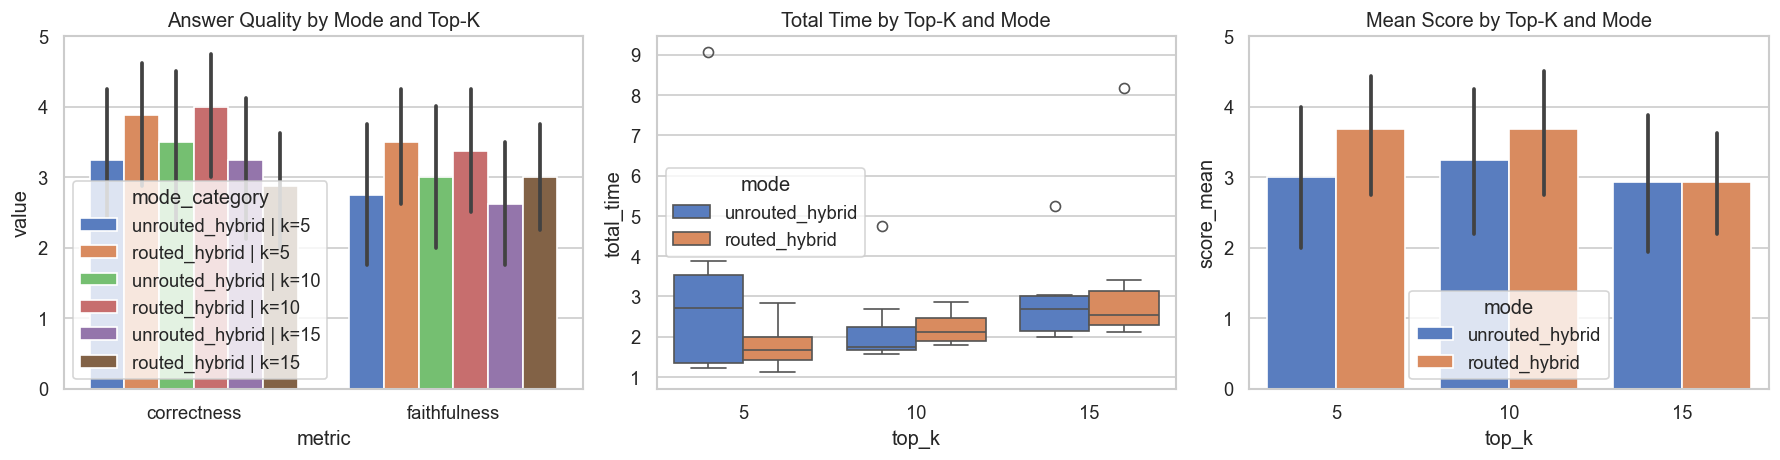

In [10]:
summary = bench_df.groupby(['top_k', 'mode', 'category']).agg(
    correctness=('correctness', 'mean'),
    faithfulness=('faithfulness', 'mean'),
    score_mean=('score_mean', 'mean'),
    retrieval_time=('retrieval_time', 'mean'),
    generation_time=('generation_time', 'mean'),
    total_time=('total_time', 'mean'),
).round(3)
overall = bench_df.groupby(['top_k', 'mode'])[['correctness', 'faithfulness', 'score_mean', 'retrieval_time', 'generation_time', 'total_time']].mean().round(3)
print('Overall benchmark summary')
display(summary)
print('Overall means')
display(overall)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
score_plot = bench_df.melt(id_vars=['question_id', 'category', 'mode', 'top_k'], value_vars=['correctness', 'faithfulness'], var_name='metric', value_name='value')
score_plot['mode_category'] = score_plot['mode'] + ' | k=' + score_plot['top_k'].astype(str)
sns.barplot(data=score_plot, x='metric', y='value', hue='mode_category', ax=axes[0])
axes[0].set_ylim(0, 5)
axes[0].set_title('Answer Quality by Mode and Top-K')
sns.boxplot(data=bench_df, x='top_k', y='total_time', hue='mode', ax=axes[1])
axes[1].set_title('Total Time by Top-K and Mode')
sns.barplot(data=bench_df, x='top_k', y='score_mean', hue='mode', ax=axes[2])
axes[2].set_ylim(0, 5)
axes[2].set_title('Mean Score by Top-K and Mode')
plt.tight_layout()
plt.show()


In [11]:
compare_df = bench_df.pivot_table(index=['top_k', 'question_id', 'category', 'question'], columns='mode', values='score_mean', aggfunc='first').reset_index()
compare_df['delta'] = compare_df['routed_hybrid'] - compare_df['unrouted_hybrid']
route_df = bench_df[bench_df['mode'] == 'routed_hybrid'][['top_k', 'question_id', 'route', 'used_docs', 'used_code']]
compare_df = compare_df.merge(route_df, on=['top_k', 'question_id'], how='left')
print('Routing impact by question')
display(compare_df.sort_values('delta', ascending=False))


Routing impact by question


,top_k,question_id,category,question,routed_hybrid,unrouted_hybrid,delta,route,used_docs,used_code
8,10,1,docs,What does KDK stand for?,4.5,1.0,3.5,docs,True,False
0,5,1,docs,What does KDK stand for?,3.5,1.0,2.5,docs,True,False
3,5,4,docs,Why is a single source of truth recommended in...,3.5,2.5,1.0,docs,True,False
1,5,2,docs,What license is used by KDK?,4.5,3.5,1.0,mixed,True,True
23,15,8,code,Which file defines addQueryParameter and URL-b...,3.5,2.5,1.0,code,False,True
4,5,5,code,Where is createService implemented on the clie...,3.5,2.5,1.0,code,False,True
22,15,7,code,Where is the useWeather composable implemented?,1.5,1.0,0.5,code,False,True
16,15,1,docs,What does KDK stand for?,1.5,1.0,0.5,docs,True,False
7,5,8,code,Which file defines addQueryParameter and URL-b...,5.0,5.0,0.0,code,False,True
6,5,7,code,Where is the useWeather composable implemented?,1.0,1.0,0.0,code,False,True


## Reading the Benchmark

This notebook gives a practical end-to-end benchmark for the final mixed pipeline.

Interpretation:

- High `correctness` with high `faithfulness` means the hybrid retrieval is surfacing the right evidence and Ollama is using it well.
- If docs questions do well but code questions lag, the next likely improvement is code-specific lexical retrieval and better code chunk metadata.
- If code questions do well but docs fact questions still fail, increase BM25 influence or route title-heavy factual queries more aggressively to docs BM25.


## Production Gaps

This notebook demonstrates a workable final prototype, but it is not yet a stable production-grade RAG system. The main missing pieces are below.

1. Query routing
- The current pipeline sends every question into all four channels: docs semantic, docs BM25, code semantic, code BM25.
- In production, queries should first be classified or routed: docs-heavy, code-heavy, or mixed. This reduces cross-corpus noise and improves faithfulness.

2. Better fusion and reranking
- RRF is a good baseline, but it is still a shallow rank-fusion method.
- A production system usually adds a reranker after retrieval so exact source code matches, acronym expansions, and key factual chunks rank above merely related chunks.

3. Corpus-specific weighting
- Different question types need different retrieval weights.
- Acronym and exact-term questions should bias toward BM25 and docs.
- Symbol lookup and file responsibility questions should bias toward BM25 and code.
- Conceptual architecture questions should bias more toward semantic retrieval.

4. Stronger code retrieval
- The retained code strategy is currently file-level because it benchmarked better than the first symbol-aware attempt.
- Production code RAG should usually support both file-level and symbol-level retrieval, with richer metadata such as imports, exports, owning module, and path tokens.

5. Better benchmark design
- The current benchmark is small and mostly file-level for code.
- Production validation needs larger benchmarks with separate labels for retrieval success, answer correctness, faithfulness, and source citation quality.
- Code benchmarks should include symbol-level targets, not only file-level targets.

6. Safer answer generation
- The current prompt asks the model to stay within context, but the benchmark still shows context leakage and partial fabrication.
- Production systems often add stricter citation requirements, answer abstention rules, and post-checks that verify source coverage before returning an answer.

7. Incremental indexing and refresh
- A production system must re-index safely as docs and code evolve.
- This usually requires file hashing, change detection, partial re-chunking, partial re-embedding, and safe replacement of outdated index entries.

8. Operational observability
- Production RAG needs logging and dashboards for retrieval hits, source distribution, latency, miss patterns, and answer quality drift.
- Without this, it is hard to know whether failures come from corpus changes, chunking regressions, embedding issues, or ranking errors.

9. Access control and source policy
- If internal code and internal docs are queried together, production deployment must respect repository boundaries, source sensitivity, and answer-time filtering.
- Not every caller should necessarily see every file or every chunk.

10. Recommended next production step
- Keep the current notebook as the reference baseline.
- Next, implement query routing plus hybrid retrieval weighting before generation.
- After that, add reranking and a larger benchmark.
- That sequence will likely improve faithfulness more than changing the generator alone.
